<a href="https://colab.research.google.com/github/mukedon/quantum_computing/blob/main/quantum_error_correction%20/2_qec_codes_methods_%26_formalism/qec_codes_methods_%26_formalism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: QEC Codes, Methods, and Stabilizer Formalism

## Overview

Chapter 1 established *what* quantum errors are. This chapter builds the complete
mathematical framework for *detecting and correcting* them.

We proceed from the foundational theory to a zoo of practical codes:

| Section | Topic | Status |
|---|---|---|
| 2.1 | The $[[n,k,d]]$ notation and code distance | Theory |
| 2.2 | Stabilizer formalism | Theory + Qiskit |
| 2.3 | 3-qubit repetition codes | **↗ see `2-3q_err_cor.ipynb`** |
| 2.4 | Shor's 9-qubit code $[[9,1,3]]$ | Full derivation |
| 2.5 | Steane code $[[7,1,3]]$ (CSS) | Full derivation |
| 2.6 | 5-qubit perfect code $[[5,1,3]]$ | Full derivation |
| 2.7 | Surface code $[[d^2,1,d]]$ | **↗ see `surface_code_tutorial.ipynb`** |
| 2.8 | Bosonic codes — GKP and cat codes | Theory + plots |
| 2.9 | Error mitigation — ZNE and PEC | Theory + Mitiq |

**Cross-references to your existing work:**

This chapter builds directly on two notebooks in this repository:

- **`2-3q_err_cor.ipynb`** — Contains the complete Qiskit implementation of
  2-qubit and 3-qubit bit-flip correction with full stabilizer syndrome extraction.
  Section 2.3 below summarises that material and points you there for the code.

- **`surface_code_tutorial.ipynb`** — Contains the advanced treatment of the
  rotated surface code using `stim` + `pymatching`, including threshold simulations,
  MWPM decoding, and lattice surgery. Section 2.7 summarises and cross-references it.

**Libraries used in this chapter:**
```python
numpy, scipy, matplotlib, qiskit, qiskit-aer, qiskit-qec, stim, pymatching, mitiq
```

---

**Key references for this chapter:**

| # | Reference |
|---|---|
| [1] | Nielsen & Chuang. *Quantum Computation and Quantum Information*. Cambridge, 2010. |
| [2] | Gottesman, D. *Stabilizer Codes and Quantum Error Correction* (PhD thesis). arXiv:quant-ph/9705052, 1997. |
| [3] | Calderbank, A. R. & Shor, P. W. Good quantum error-correcting codes exist. *Phys. Rev. A* **54**, 1098 (1996). |
| [4] | Steane, A. M. Multiple particle interference and quantum error correction. *Proc. R. Soc. Lond. A* **452**, 2551 (1996). |
| [5] | Shor, P. W. Scheme for reducing decoherence in quantum computer memory. *Phys. Rev. A* **52**, R2493 (1995). |
| [6] | Laflamme, R. et al. Perfect quantum error correcting code. *Phys. Rev. Lett.* **77**, 198 (1996). |
| [7] | Kitaev, A. Yu. Fault-tolerant quantum computation by anyons. *Ann. Phys.* **303**, 2–30 (2003). |
| [8] | Fowler, A. M. et al. Surface codes: Towards practical large-scale quantum computation. *Phys. Rev. A* **86**, 032324 (2012). |
| [9] | Gottesman, D. & Kitaev, A. Demonstrating the viability of universal quantum computation using teleportation and single-qubit operations. *Nature* **402**, 390 (1999). |
| [10] | Grimm, A. et al. Stabilization and operation of a Kerr-cat qubit. *Nature* **584**, 205–209 (2020). |
| [11] | Temme, K. et al. Error mitigation for short-depth quantum circuits. *Phys. Rev. Lett.* **119**, 180509 (2017). |
| [12] | Li, Y. & Benjamin, S. C. Efficient variational quantum simulator incorporating active error minimization. *Phys. Rev. X* **7**, 021050 (2017). |
| [13] | Qiskit QEC: https://github.com/qiskit-community/qiskit-qec |
| [14] | Mitiq documentation: https://mitiq.readthedocs.io |
| [15] | PennyLane QEC codebook: https://pennylane.ai/codebook/quantum-error-correction |
| [16] | Quillen, A. C. *Introducing Quantum Error Correction*. PHY265 notes. https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |

In [2]:
!pip install qiskit
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
from functools import reduce

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import (
    Statevector, DensityMatrix, Operator,
    Pauli, SparsePauliOp, StabilizerState, Clifford,
    state_fidelity, random_clifford
)
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Pauli matrices (carry over from Chapter 1 for standalone use)
I_m = np.eye(2, dtype=complex)
X_m = np.array([[0,1],[1,0]], dtype=complex)
Y_m = np.array([[0,-1j],[1j,0]], dtype=complex)
Z_m = np.array([[1,0],[0,-1]], dtype=complex)

def kron(*ops):
    """Tensor product of an arbitrary list of 2x2 matrices."""
    return reduce(np.kron, ops)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports successful.")

Imports successful.


---
## 2.1 The $[[n, k, d]]$ Notation and Code Distance

### 2.1.1 Encoding map

A quantum error-correcting code is a map from a $k$-qubit *logical* Hilbert space
$\mathcal{H}_L \cong (\mathbb{C}^2)^{\otimes k}$ into an $n$-qubit *physical* Hilbert
space $\mathcal{H}_P \cong (\mathbb{C}^2)^{\otimes n}$:

$$\mathcal{H}_L \;\xrightarrow{\;\text{encode}\;}\; \mathcal{C} \subset \mathcal{H}_P,
\qquad \dim \mathcal{C} = 2^k$$

The subspace $\mathcal{C}$ is called the **codespace** or **code subspace**.
The $n-k$ extra physical qubits provide redundancy that allows error detection.

### 2.1.2 The $[[n, k, d]]$ parameters

A code is characterised by three integers $[[n, k, d]]$:

| Parameter | Meaning |
|---|---|
| $n$ | Number of **physical** qubits |
| $k$ | Number of **logical** qubits encoded ($k < n$) |
| $d$ | **Code distance**: minimum weight of any undetectable error |

The **weight** of a Pauli error $E \in \mathcal{P}_n$ is the number of qubits on
which $E$ acts non-trivially (not as $I$):
$$\text{wt}(E) = |\{i : E_i \neq I\}|$$

A code of distance $d$ can:
- **Detect** all errors of weight $\leq d-1$
- **Correct** all errors of weight $\leq t = \lfloor(d-1)/2\rfloor$

**Example:** $[[7,1,3]]$ (Steane code)
- $n=7$ physical qubits, $k=1$ logical qubit
- Distance $d=3$, so $t=1$: corrects any single-qubit error
- Rate $k/n = 1/7$

### 2.1.3 Comparison of major codes

The table below compares all codes covered in this chapter for $k=1$, $d=3$
(corrects any single-qubit error):

| Code | $[[n,k,d]]$ | Type | Key property |
|---|---|---|---|
| 3-qubit (bit-flip only) | $[[3,1,1]]^*$ | Repetition | Detects bit flips only |
| Shor | $[[9,1,3]]$ | Concatenated | First QEC code; corrects $X$, $Y$, $Z$ |
| 5-qubit | $[[5,1,3]]$ | Stabilizer | Theoretical minimum for $d=3$, $k=1$ |
| Steane | $[[7,1,3]]$ | CSS | Efficient; transversal Clifford gates |
| Surface ($d=3$) | $[[13\text{–}17,1,3]]$ | Topological | High threshold ($\sim 1\%$); local 2D |
| Rotated surface ($d=3$) | $[[9,1,3]]$ | Topological | Half the qubits of standard surface |

*\*The 3-qubit code corrects bit flips only; it has distance $d=3$ against $X$ errors
but $d=1$ against $Z$ errors. True distance requires protection against all Paulis.*

### 2.1.4 Quantum Hamming bound

For a non-degenerate $[[n,1,2t+1]]$ code (correcting $t$ errors on $n$ qubits):

$$\sum_{j=0}^{t} \binom{n}{j} 3^j \leq 2^{n-1}$$

This is the quantum analogue of the classical Hamming bound. The factor $3^j$ counts
the $\binom{n}{j}$ error locations times the 3 non-trivial Paulis per qubit.

The **5-qubit code** $[[5,1,3]]$ saturates this bound for $t=1, n=5$:
$$\binom{5}{0}3^0 + \binom{5}{1}3^1 = 1 + 15 = 16 = 2^{5-1} \;\checkmark$$
It is therefore a **perfect code** — the minimum possible number of physical qubits
to encode 1 logical qubit with $d=3$.

Quantum Hamming bound:  Σ_{j=0}^{t} C(n,j) * 3^j  ≤  2^{n-1}
(For k=1, non-degenerate codes)

   n    t      LHS      RHS   Satisfies   Saturates
-------------------------------------------------------
   5    1       16       16           ✓   ★ PERFECT
   6    1       19       32           ✓            
   7    1       22       64           ✓            
   8    1       25      128           ✓            
   9    1       28      256           ✓            
  10    1       31      512           ✓            
  10    2      436      512           ✓            
  11    1       34     1024           ✓            
  11    2      529     1024           ✓            
  12    1       37     2048           ✓            
  12    2      631     2048           ✓            

Perfect codes found (saturate bound): [(5, 1, 16, 16)]

→ [[5,1,3]] (t=1, n=5): LHS=16=RHS=16 — saturates the bound.


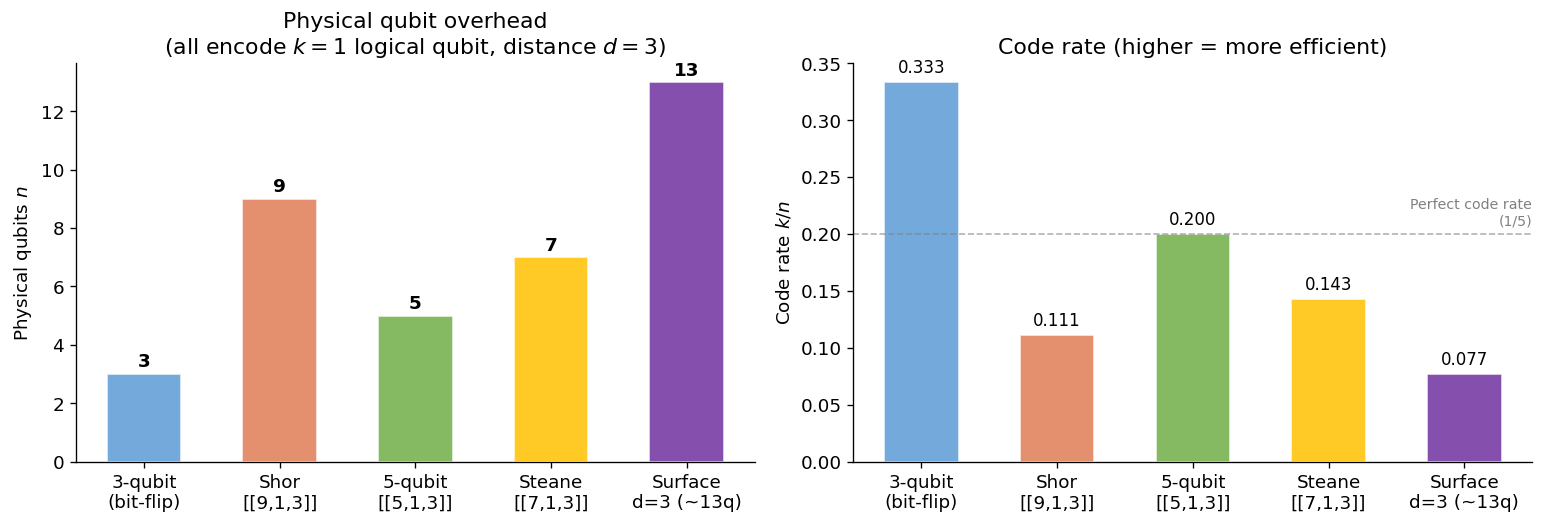

In [3]:
# ── Quantum Hamming bound: which (n,t) pairs satisfy it? ────────────────────
from math import comb

print("Quantum Hamming bound:  Σ_{j=0}^{t} C(n,j) * 3^j  ≤  2^{n-1}")
print("(For k=1, non-degenerate codes)\n")
print(f"{'n':>4} {'t':>4} {'LHS':>8} {'RHS':>8}  {'Satisfies':>10}  {'Saturates':>10}")
print("-" * 55)

perfect_codes = []
for n in range(1, 20):
    for t in range(1, (n+1)//2 + 1):
        lhs = sum(comb(n, j) * 3**j for j in range(t+1))
        rhs = 2**(n-1)
        ok = lhs <= rhs
        sat = lhs == rhs
        if sat:
            perfect_codes.append((n, t, lhs, rhs))
        if n <= 12 and ok:
            print(f"{n:>4} {t:>4} {lhs:>8} {rhs:>8}  {'✓':>10}  {'★ PERFECT' if sat else '':>10}")

print(f"\nPerfect codes found (saturate bound): {perfect_codes}")
print("\n→ [[5,1,3]] (t=1, n=5): LHS=16=RHS=16 — saturates the bound.")

# ── Parameter comparison bar chart ──────────────────────────────────────────
codes = {
    "3-qubit\n(bit-flip)": (3, 1, "Repetition", "#5b9bd5"),
    "Shor\n[[9,1,3]]":     (9, 1, "Concatenated", "#e07b54"),
    "5-qubit\n[[5,1,3]]":  (5, 1, "Perfect", "#70ad47"),
    "Steane\n[[7,1,3]]":   (7, 1, "CSS", "#ffc000"),
    "Surface\nd=3 (~13q)": (13, 1, "Topological", "#7030a0"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

names = list(codes.keys())
n_vals  = [v[0] for v in codes.values()]
colors_ = [v[3] for v in codes.values()]

ax1 = axes[0]
bars = ax1.bar(names, n_vals, color=colors_, alpha=0.85, edgecolor='white', width=0.55)
ax1.set_ylabel("Physical qubits $n$")
ax1.set_title("Physical qubit overhead\n(all encode $k=1$ logical qubit, distance $d=3$)")
for bar, n in zip(bars, n_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, n + 0.1, str(n),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Rate k/n
ax2 = axes[1]
rates = [1/v[0] for v in codes.values()]
bars2 = ax2.bar(names, rates, color=colors_, alpha=0.85, edgecolor='white', width=0.55)
ax2.set_ylabel("Code rate $k/n$")
ax2.set_title("Code rate (higher = more efficient)")
for bar, r in zip(bars2, rates):
    ax2.text(bar.get_x() + bar.get_width()/2, r + 0.005,
             f"{r:.3f}", ha='center', va='bottom', fontsize=10)
ax2.axhline(1/5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(4.5, 1/5 + 0.008, 'Perfect code rate\n(1/5)', fontsize=8.5, color='gray', ha='right')

plt.tight_layout()
plt.show()

---
## 2.2 The Stabilizer Formalism

The stabilizer formalism, introduced by Gottesman [2], provides a compact and powerful
language for describing QEC codes without needing to write down all $2^n$ amplitudes
of the state.

### 2.2.1 The Pauli group

The $n$-qubit **Pauli group** is:

$$\mathcal{P}_n = \{\pm 1, \pm i\} \times \{I, X, Y, Z\}^{\otimes n}$$

Elements of $\mathcal{P}_n$ are tensor products of single-qubit Paulis with a phase.
For example, $iX \otimes Z \otimes I \in \mathcal{P}_3$.

Key fact: any two Paulis either **commute** or **anticommute**:
$$[P, Q] = 0 \quad \text{or} \quad \{P, Q\} = 0, \quad \forall P, Q \in \mathcal{P}_n$$

Single-qubit Paulis: $XZ = -ZX$ (anticommute), $XY = iZ$ (cyclic).

### 2.2.2 Stabilizer group and codespace

A **stabilizer group** $\mathcal{S}$ is an Abelian (commuting) subgroup of
$\mathcal{P}_n$ that does not contain $-I$:

$$\mathcal{S} = \langle g_1, g_2, \ldots, g_{n-k} \rangle, \quad g_i \in \mathcal{P}_n,
\quad [g_i, g_j] = 0 \; \forall i,j$$

The **codespace** is the simultaneous $+1$ eigenspace of all generators:

$$\mathcal{C} = \{|\psi\rangle \in (\mathbb{C}^2)^{\otimes n} : g_i|\psi\rangle = +|\psi\rangle \;\forall i\}$$

**Why $+1$ eigenvalue?** Each $g_i$ has eigenvalues $\pm 1$. Fixing them all to $+1$
selects a $2^k$-dimensional subspace (since $n-k$ independent constraints each halve
the space: $2^n / 2^{n-k} = 2^k$).

### 2.2.3 Syndrome measurement

Suppose an error $E \in \mathcal{P}_n$ acts on a codestate $|\psi\rangle \in \mathcal{C}$.
The corrupted state is $E|\psi\rangle$. For each stabilizer $g_i$:

$$g_i (E|\psi\rangle) = \begin{cases}
+E|\psi\rangle & \text{if } [g_i, E] = 0 \; (E \text{ commutes with } g_i) \\
-E|\psi\rangle & \text{if } \{g_i, E\} = 0 \; (E \text{ anticommutes with } g_i)
\end{cases}$$

Measuring $g_i$ on $E|\psi\rangle$ gives outcome $s_i = \pm 1$. The **syndrome** is the
binary string $\mathbf{s} = (s_1, \ldots, s_{n-k}) \in \{0,1\}^{n-k}$ where $s_i = 0$
if outcome $+1$ and $s_i = 1$ if outcome $-1$.

**Key properties of syndrome measurement:**
1. It reveals which error occurred (through the syndrome pattern) without measuring
   the logical state (because errors are in the *error subspace*, orthogonal to $\mathcal{C}$).
2. The syndrome is a deterministic function of the error: $s_i = \frac{1 - g_i E g_i^\dagger / E}{2}$
   expressed in terms of commutation.
3. Two errors $E_1, E_2$ with the same syndrome are **degenerate** — the code cannot
   distinguish them. This is fine as long as $E_1^\dagger E_2 \in \mathcal{S}$.

### 2.2.4 Correctable error conditions

A set of errors $\{E_a\}$ is **correctable** by the code $\mathcal{C}$ if and only if
(Knill–Laflamme conditions [1]):

$$P_\mathcal{C} E_a^\dagger E_b P_\mathcal{C} = C_{ab} P_\mathcal{C}$$

where $P_\mathcal{C}$ is the projector onto the codespace and $C_{ab}$ is a Hermitian
matrix. In the stabilizer picture, this means:

For all $E_a, E_b$ in the error set:
- Either $E_a^\dagger E_b$ **anticommutes with some generator** $g_i$
  (distinct syndromes → distinguishable, correctable), **or**
- $E_a^\dagger E_b \in \mathcal{S}$ (same syndrome → degenerate, also correctable)

### 2.2.5 Logical operators

The **logical operators** $\bar{X}$ and $\bar{Z}$ (for $k=1$) are Pauli operators that:
1. **Commute** with all stabilizer generators (so they preserve the codespace)
2. Are **not** in the stabilizer group (so they actually act non-trivially on the logical state)

They satisfy the same algebra as physical Paulis: $\bar{X}\bar{Z} = -\bar{Z}\bar{X}$.

The code distance $d$ is the **minimum weight** of any logical operator:
$$d = \min_{L \in \bar{\mathcal{L}} \setminus \mathcal{S}} \text{wt}(L)$$
where $\bar{\mathcal{L}}$ is the **normalizer** of $\mathcal{S}$ in $\mathcal{P}_n$:
$\bar{\mathcal{L}} = \{P \in \mathcal{P}_n : [P, g_i] = 0 \; \forall g_i \in \mathcal{S}\}$.

In [4]:
# ── Pauli commutation check (binary symplectic representation) ───────────────
# A Pauli P on n qubits is represented as a binary vector (x|z) ∈ F_2^{2n}
# P = X^{x_1} Z^{z_1} ⊗ ... ⊗ X^{x_n} Z^{z_n}  (ignoring phase)
# Two Paulis P=(x1|z1), Q=(x2|z2) commute iff x1·z2 + x2·z1 = 0 (mod 2)

def pauli_to_bsv(pauli_str: str) -> np.ndarray:
    """Convert a Pauli string like 'XZIY' to binary symplectic vector (x|z)."""
    n = len(pauli_str)
    xv = np.zeros(n, dtype=int)
    zv = np.zeros(n, dtype=int)
    for i, c in enumerate(pauli_str):
        if c == 'X': xv[i] = 1
        elif c == 'Z': zv[i] = 1
        elif c == 'Y': xv[i] = 1; zv[i] = 1
    return np.concatenate([xv, zv])

def commutes(p1: str, p2: str) -> bool:
    """Return True if Pauli strings p1 and p2 commute."""
    v1 = pauli_to_bsv(p1)
    v2 = pauli_to_bsv(p2)
    n = len(p1)
    x1, z1 = v1[:n], v1[n:]
    x2, z2 = v2[:n], v2[n:]
    return int(x1 @ z2 + x2 @ z1) % 2 == 0

def syndrome(error: str, generators: list) -> np.ndarray:
    """Compute the syndrome of an error given stabilizer generators."""
    return np.array([0 if commutes(error, g) else 1 for g in generators])


# ── Demo: 3-qubit bit-flip code stabilizers ──────────────────────────────────
print("=== 3-qubit bit-flip code ===")
print("Stabilizer generators: S1=ZZI, S2=IZZ")
generators_3q = ['ZZI', 'IZZ']

errors_3q = ['III', 'XII', 'IXI', 'IIX']
error_names = ['No error', 'X on q1', 'X on q2', 'X on q3']

print(f"\n{'Error':>10} | {'Syndrome':>12} | {'Corrective action':>20}")
print("-" * 48)
for err, name in zip(errors_3q, error_names):
    syn = syndrome(err, generators_3q)
    print(f"{err:>10} | {str(syn):>12} | {name:>20}")

# Verify generators commute with each other
print(f"\nS1 commutes with S2: {commutes('ZZI', 'IZZ')}")
print(f"X1 anticommutes with S1 (ZZI): {not commutes('XII', 'ZZI')}")
print(f"X2 anticommutes with S1 AND S2: {not commutes('IXI','ZZI')} AND {not commutes('IXI','IZZ')}")


# ── Qiskit StabilizerState for the 3-qubit bit-flip code ─────────────────────
print("\n=== Qiskit StabilizerState demo ===")
# Encode |0> logically: prepare |000>
qc_enc = QuantumCircuit(3)
# Encoding: apply CNOT from q0 to q1 and q0 to q2
qc_enc.cx(0, 1)
qc_enc.cx(0, 2)

cliff = Clifford(qc_enc)
stab_state = StabilizerState(qc_enc)
print(f"Stabilizer generators (Qiskit): {cliff.to_labels()}")
print(f"  Format: (destabilizers | stabilizers)")

# Inject X error on qubit 1 and re-check
qc_err = QuantumCircuit(3)
qc_err.cx(0,1); qc_err.cx(0,2)
qc_err.x(1)    # inject error
cliff_err = Clifford(qc_err)
print(f"\nAfter X error on q1: {cliff_err.to_labels()}")
print("→ Syndrome extraction circuit is shown in 2-3q_err_cor.ipynb, Section 3")

=== 3-qubit bit-flip code ===
Stabilizer generators: S1=ZZI, S2=IZZ

     Error |     Syndrome |    Corrective action
------------------------------------------------
       III |        [0 0] |             No error
       XII |        [1 0] |              X on q1
       IXI |        [1 1] |              X on q2
       IIX |        [0 1] |              X on q3

S1 commutes with S2: True
X1 anticommutes with S1 (ZZI): True
X2 anticommutes with S1 AND S2: True AND True

=== Qiskit StabilizerState demo ===
Stabilizer generators (Qiskit): ['+XXX', '+IXI', '+XII', '+IIZ', '+IZZ', '+ZIZ']
  Format: (destabilizers | stabilizers)

After X error on q1: ['+XXX', '+IXI', '+XII', '+IIZ', '-IZZ', '+ZIZ']
→ Syndrome extraction circuit is shown in 2-3q_err_cor.ipynb, Section 3


---
## 2.3 The 3-Qubit Repetition Codes

> **↗ Cross-reference:** The full Qiskit implementation — including the 2-qubit Bell
> state stabilizer, the 3-qubit bit-flip code with ancilla syndrome extraction, and
> the 3-qubit phase-flip code — is worked through in detail in:
>
> **[`2-3q_err_cor.ipynb`](./2-3q_err_cor.ipynb)**
>
> That notebook covers (with complete Qiskit circuits and running code):
> - Stabilizer generators $S_1 = Z_1Z_2$, $S_2 = Z_2Z_3$
> - Syndrome table for all single-qubit $X$ errors
> - Full ancilla-based syndrome extraction circuit
> - Recovery map: $(−1,+1) \to X_1$, $(−1,−1) \to X_2$, $(+1,−1) \to X_3$
> - Why the code fails for $Z$ (phase) errors

### Summary of results from `2-3q_err_cor.ipynb`

**Encoding:**
$$|0\rangle_L = |000\rangle, \qquad |1\rangle_L = |111\rangle$$
$$|\psi\rangle_L = \alpha|000\rangle + \beta|111\rangle$$

**Stabilizer generators** ($k=1$, $n=3$, $d=3$ for $X$ errors, $d=1$ for $Z$ errors):
$$S_1 = Z_1 Z_2 \otimes I_3, \qquad S_2 = I_1 \otimes Z_2 Z_3$$

**Syndrome table:**

| Error | $S_1 = Z_1Z_2$ | $S_2 = Z_2Z_3$ | Syndrome | Action |
|---|---|---|---|---|
| $I$ (none) | $+1$ | $+1$ | $(0,0)$ | Do nothing |
| $X_1$ | $-1$ | $+1$ | $(1,0)$ | Apply $X_1$ |
| $X_2$ | $-1$ | $-1$ | $(1,1)$ | Apply $X_2$ |
| $X_3$ | $+1$ | $-1$ | $(0,1)$ | Apply $X_3$ |

**Logical operators:**
$$\bar{X} = X_1 X_2 X_3, \qquad \bar{Z} = Z_1 \;(= Z_2 = Z_3 \text{ in codespace})$$

**Limitation:** $Z$ (phase) errors produce syndrome $(0,0)$ — they are invisible to
the $Z_i Z_j$ stabilizers. The code requires the **phase-flip code** to handle them,
leading naturally to Shor's 9-qubit code (Section 2.4).

*See `2-3q_err_cor.ipynb` for the full working Qiskit implementation.*

---
## 2.4 Shor's 9-Qubit Code $[[9,1,3]]$

Shor's code [5] was the first QEC code to protect against arbitrary single-qubit errors
(both $X$ and $Z$). It is a **concatenated code**: a phase-flip repetition code on the
outer level, and a bit-flip repetition code on the inner level.

### 2.4.1 Encoding

The logical basis states are:

$$|0\rangle_L = \frac{1}{2\sqrt{2}}(|000\rangle + |111\rangle)^{\otimes 3}$$

$$|1\rangle_L = \frac{1}{2\sqrt{2}}(|000\rangle - |111\rangle)^{\otimes 3}$$

More compactly, define $|+_L\rangle = (|000\rangle + |111\rangle)/\sqrt{2}$ and
$|-_L\rangle = (|000\rangle - |111\rangle)/\sqrt{2}$. Then:

$$|0\rangle_L = |{+_L}{+_L}{+_L}\rangle, \qquad |1\rangle_L = |{-_L}{-_L}{-_L}\rangle$$

The 9 physical qubits are arranged in 3 blocks of 3: qubits $(1,2,3)$, $(4,5,6)$, $(7,8,9)$.

**Encoding circuit:**
1. Start with $|\psi\rangle|0\rangle^{\otimes 8}$.
2. Apply CNOT$_{1\to4}$ and CNOT$_{1\to7}$ to get phase-flip repetition.
3. Apply $H$ to qubits 1, 4, 7.
4. Apply CNOT$_{1\to2}$, CNOT$_{1\to3}$, CNOT$_{4\to5}$, CNOT$_{4\to6}$,
   CNOT$_{7\to8}$, CNOT$_{7\to9}$ for bit-flip repetition within each block.

### 2.4.2 Stabilizer generators

The Shor code has $n - k = 8$ stabilizer generators:

**Bit-flip stabilizers** (detect $X$ errors within each block of 3):
$$g_1 = Z_1Z_2I_3I_4I_5I_6I_7I_8I_9 \equiv Z_1Z_2$$
$$g_2 = I_1Z_2Z_3I_4I_5I_6I_7I_8I_9 \equiv Z_2Z_3$$
$$g_3 = Z_4Z_5, \quad g_4 = Z_5Z_6, \quad g_5 = Z_7Z_8, \quad g_6 = Z_8Z_9$$

**Phase-flip stabilizers** (detect $Z$ errors across blocks):
$$g_7 = X_1X_2X_3X_4X_5X_6 \equiv \overline{X \otimes X}$$
$$g_8 = X_4X_5X_6X_7X_8X_9 \equiv \overline{X \otimes X}$$

**Logical operators** (weight-3 each):
$$\bar{X} = X_1X_2X_3 \qquad (\text{or } X_4X_5X_6 \text{ or } X_7X_8X_9)$$
$$\bar{Z} = Z_1Z_4Z_7 \qquad (\text{one qubit from each block})$$

### 2.4.3 Error correction mechanism

**Correcting a $Z$ error on qubit 1:**
The $Z$ error anticommutes with $g_7$ (since $g_7$ has $X$'s on qubits 1–6):
$Z_1 X_1 X_2 X_3 X_4 X_5 X_6 = -X_1 X_2 X_3 X_4 X_5 X_6 Z_1$.
Syndrome: $g_7 \to -1$, $g_8 \to +1$. Correction: apply $Z_1$.

**Correcting an $X$ error on qubit 1:**
The $X$ error anticommutes with $g_1 = Z_1Z_2$:
$X_1 Z_1 Z_2 = -Z_1 X_1 Z_2$. Syndrome: $g_1 \to -1$, $g_2 \to +1$. Correction: apply $X_1$.

**Correcting a $Y = iXZ$ error:** Apply the $X$ and $Z$ corrections in sequence.
Since the code can correct both types independently, it handles $Y$ automatically.

This demonstrates the **Pauli error discretization**: a continuous rotation
$\cos\theta I + i\sin\theta X$ on qubit 1 is projected by syndrome measurement
onto the outcome "no error" (probability $\cos^2\theta$) or "X error"
(probability $\sin^2\theta$), and corrected accordingly.

In [5]:
# ── Shor code: encoding circuit ──────────────────────────────────────────────
def shor_encoding_circuit() -> QuantumCircuit:
    """
    Build the Shor 9-qubit encoding circuit.
    Qubit layout: q0..q8.  Logical input qubit: q0.
    Assumes q0 is prepared in |ψ⟩ = α|0⟩ + β|1⟩ before calling.

    Steps:
      1. Phase-flip repetition (CNOT q0→q3, q0→q6)
      2. Hadamard on each block leader (q0, q3, q6)
      3. Bit-flip repetition within each block
    """
    qc = QuantumCircuit(9, name='Shor_encode')
    qc.cx(0, 3); qc.cx(0, 6)          # phase-flip layer
    qc.h(0);  qc.h(3);  qc.h(6)       # Hadamard on block leaders
    qc.cx(0, 1); qc.cx(0, 2)           # block 1
    qc.cx(3, 4); qc.cx(3, 5)           # block 2
    qc.cx(6, 7); qc.cx(6, 8)           # block 3
    return qc


def shor_syndrome_circuit() -> QuantumCircuit:
    """
    Shor code syndrome extraction.
    17 qubits: data[0..8] + ancilla[0..7].
    Measures stabilizers g1..g8 into classical register 'syn'.

    Z-type stabilizers (g1–g6): measure via CNOT data→ancilla.
    X-type stabilizers (g7–g8): measure via H–CNOT(anc→data)–H.
    """
    data = QuantumRegister(9, 'data')
    anc  = QuantumRegister(8, 'anc')
    cr   = ClassicalRegister(8, 'syn')
    qc   = QuantumCircuit(data, anc, cr)

    # ── Z-type stabilizers: CNOT data→ancilla ──────────────────────────────
    # g1 = Z₀Z₁
    qc.cx(data[0], anc[0]); qc.cx(data[1], anc[0])
    # g2 = Z₁Z₂
    qc.cx(data[1], anc[1]); qc.cx(data[2], anc[1])
    # g3 = Z₃Z₄
    qc.cx(data[3], anc[2]); qc.cx(data[4], anc[2])
    # g4 = Z₄Z₅
    qc.cx(data[4], anc[3]); qc.cx(data[5], anc[3])
    # g5 = Z₆Z₇
    qc.cx(data[6], anc[4]); qc.cx(data[7], anc[4])
    # g6 = Z₇Z₈
    qc.cx(data[7], anc[5]); qc.cx(data[8], anc[5])

    # ── X-type stabilizers: H–CNOT(anc→data)–H ─────────────────────────────
    # CRITICAL: H must wrap ALL CNOTs as a single block, not each individually.
    # H inside the loop gives H·CX·H | H·CX·H | … where adjacent HH = I,
    # which does NOT measure the joint X product.

    # g7 = X₀X₁X₂X₃X₄X₅
    qc.h(anc[6])
    for i in range(6):
        qc.cx(anc[6], data[i])
    qc.h(anc[6])

    # g8 = X₃X₄X₅X₆X₇X₈
    qc.h(anc[7])
    for i in range(3, 9):
        qc.cx(anc[7], data[i])
    qc.h(anc[7])

    qc.measure(anc, cr)
    return qc


# ── Stabilizer generators (single clean definition) ───────────────────────────
# Qubits 0–8, blocks: (0,1,2), (3,4,5), (6,7,8)
shor_generators = [
    'ZZIIIIIII',  # g1: Z₀Z₁  — bit-flip pair, block 1
    'IZZIIIIII',  # g2: Z₁Z₂  — bit-flip pair, block 1
    'IIIZZIIII',  # g3: Z₃Z₄  — bit-flip pair, block 2
    'IIIIZZIII',  # g4: Z₄Z₅  — bit-flip pair, block 2
    'IIIIIIZZI',  # g5: Z₆Z₇  — bit-flip pair, block 3
    'IIIIIIIZZ',  # g6: Z₇Z₈  — bit-flip pair, block 3
    'XXXXXXIII',  # g7: X₀X₁X₂X₃X₄X₅ — phase-flip, blocks 1&2
    'IIIXXXXXX',  # g8: X₃X₄X₅X₆X₇X₈ — phase-flip, blocks 2&3
]

print("Shor code stabilizer generators:")
for i, g in enumerate(shor_generators, 1):
    print(f"  g{i} = {g}")

# ── Verify all generator pairs commute ───────────────────────────────────────
all_commute = True
for i in range(8):
    for j in range(i+1, 8):
        if not commutes(shor_generators[i], shor_generators[j]):
            print(f"  ⚠ g{i+1} and g{j+1} do not commute!")
            all_commute = False
print(f"\nAll generator pairs commute: {all_commute} ✓")

# ── Syndrome table ────────────────────────────────────────────────────────────
print("\nSyndrome table (selected single-qubit errors):")
test_errors = {
    'No error': 'IIIIIIIII',
    'X on q0':  'XIIIIIIII',
    'X on q1':  'IXIIIIIII',
    'X on q4':  'IIIIIXIII',
    'Z on q0':  'ZIIIIIIII',
    'Z on q3':  'IIIZIIIII',
    'Z on q6':  'IIIIIIIZI',
    'Y on q0':  'YIIIIIIII',
}
print(f"{'Error':>12} | {'g1 g2 g3 g4 g5 g6 g7 g8':>24}")
print("-" * 42)
for name, err in test_errors.items():
    syn = syndrome(err, shor_generators)
    print(f"{name:>12} | {'  '.join(map(str, syn))}")

# ── Draw encoding circuit ─────────────────────────────────────────────────────
qc_shor = shor_encoding_circuit()
print(f"\nShor encoding circuit ({qc_shor.num_qubits} qubits, depth {qc_shor.depth()}):")
print(qc_shor.draw(output='text', fold=100))

Shor code stabilizer generators:
  g1 = ZZIIIIIII
  g2 = IZZIIIIII
  g3 = IIIZZIIII
  g4 = IIIIZZIII
  g5 = IIIIIIZZI
  g6 = IIIIIIIZZ
  g7 = XXXXXXIII
  g8 = IIIXXXXXX

All generator pairs commute: True ✓

Syndrome table (selected single-qubit errors):
       Error |  g1 g2 g3 g4 g5 g6 g7 g8
------------------------------------------
    No error | 0  0  0  0  0  0  0  0
     X on q0 | 1  0  0  0  0  0  0  0
     X on q1 | 1  1  0  0  0  0  0  0
     X on q4 | 0  0  0  1  0  0  0  0
     Z on q0 | 0  0  0  0  0  0  1  0
     Z on q3 | 0  0  0  0  0  0  1  1
     Z on q6 | 0  0  0  0  0  0  0  1
     Y on q0 | 1  0  0  0  0  0  1  0

Shor encoding circuit (9 qubits, depth 5):
               ┌───┐          
q_0: ──■────■──┤ H ├──■────■──
       │    │  └───┘┌─┴─┐  │  
q_1: ──┼────┼───────┤ X ├──┼──
       │    │       └───┘┌─┴─┐
q_2: ──┼────┼────────────┤ X ├
     ┌─┴─┐  │  ┌───┐     └───┘
q_3: ┤ X ├──┼──┤ H ├──■────■──
     └───┘  │  └───┘┌─┴─┐  │  
q_4: ───────┼───────┤ X ├──┼──
     

---
## 2.5 Steane Code $[[7,1,3]]$

The Steane code [4] is a **CSS (Calderbank–Shor–Steane) code** [3, 4] built from the
classical $[7,4,3]$ Hamming code. It was the first QEC code with $d=3$ more efficient
than Shor's 9-qubit code. A key advantage is that the Clifford group acts
**transversally** — applying a single-qubit gate to each physical qubit implements
the corresponding logical gate without spreading errors.

### 2.5.1 CSS construction

A CSS code is built from two classical binary codes $C_1 \supseteq C_2$:

$$\text{CSS}(C_1, C_2): \quad |x + C_2\rangle = \frac{1}{\sqrt{|C_2|}} \sum_{y \in C_2} |x+y\rangle, \quad x \in C_1$$

- $X$-stabilizers come from the **parity check matrix** $H_Z$ of $C_1$
- $Z$-stabilizers come from the **parity check matrix** $H_X$ of $C_2^\perp$

For the Steane code, both codes are the $[7,4,3]$ Hamming code $C_1 = C_2 = C$,
with parity check matrix:

$$H = \begin{pmatrix}
0 & 0 & 0 & 1 & 1 & 1 & 1 \\
0 & 1 & 1 & 0 & 0 & 1 & 1 \\
1 & 0 & 1 & 0 & 1 & 0 & 1
\end{pmatrix}$$

### 2.5.2 Stabilizer generators

The 6 stabilizer generators of the Steane code are read directly from $H$:

| Generator | String | Type |
|---|---|---|
| $g_1$ | $IIIXXXX$ | $X$-type |
| $g_2$ | $IXXIIXX$ | $X$-type |
| $g_3$ | $XIXIXIX$ | $X$-type |
| $g_4$ | $IIIZZZZ$ | $Z$-type |
| $g_5$ | $IZZIIZZ$ | $Z$-type |
| $g_6$ | $ZIZIZIZ$ | $Z$-type |

**Verification:**
- The $X$-generators and $Z$-generators each come from the same Hamming matrix,
  so $g_i^X g_j^Z = g_j^Z g_i^X$ for all $i,j$ (they commute since
  $H H^T = \mathbf{0}$ for the Hamming code over $\mathbb{F}_2$).
- The $X$-generators commute among themselves, and similarly for $Z$-generators.

### 2.5.3 Logical operators

$$\bar{X} = X_1X_2X_3X_4X_5X_6X_7 \qquad (\text{weight 7})$$
$$\bar{Z} = Z_1Z_2Z_3Z_4Z_5Z_6Z_7 \qquad (\text{weight 7})$$

Both have weight 7, which is consistent with $d=3$:
the minimum-weight logical operator of weight $d=3$ is found by coset representatives —
the full-weight operator $\bar{X}$ differs from a weight-3 representative by elements
of the stabilizer group.

### 2.5.4 Transversal gates

A **transversal gate** applies a gate independently to each physical qubit. These are
naturally fault-tolerant because an error on one physical qubit affects only one
logical location.

For the Steane code:
- $\bar{H} = H^{\otimes 7}$ (Hadamard on all 7 qubits implements logical Hadamard)
- $\bar{X} = X^{\otimes 7}$, $\bar{Z} = Z^{\otimes 7}$
- $\bar{S} = S^{\otimes 7}$ (phase gate, up to Pauli correction)
- $\overline{\text{CNOT}} = \text{CNOT}^{\otimes 7}$ (between two logical blocks)

The Clifford group on the logical qubit is thus **transversally implementable** —
this is a major practical advantage over the 5-qubit code.

**By the Eastin–Knill theorem**, no code can implement a universal gate set
transversally. For the Steane code, the $T$ gate (non-Clifford, needed for
universality) requires **magic state distillation**.

In [7]:
# ── Classical [7,4,3] Hamming parity check matrix ────────────────────────────
H_hamming = np.array([
    [0, 0, 0, 1, 1, 1, 1],   # row 0
    [0, 1, 1, 0, 0, 1, 1],   # row 1
    [1, 0, 1, 0, 1, 0, 1],   # row 2
], dtype=int)

print("=== Classical [7,4,3] Hamming code parity check matrix H ===")
print(H_hamming)

# Verify: H H^T = 0 mod 2  (rows are mutually orthogonal)
print(f"\nH H^T mod 2 =\n{(H_hamming @ H_hamming.T) % 2}")
print("→ All zeros: rows are orthogonal over F₂, so CSS construction is valid.")

# ── Steane code generators from H ────────────────────────────────────────────
# X-type: replace 1→X, 0→I  using rows of H
# Z-type: replace 1→Z, 0→I  using rows of H
def row_to_pauli(row: np.ndarray, pauli_char: str) -> str:
    return ''.join(pauli_char if b else 'I' for b in row)

steane_generators = []
print("\nSteane code stabilizer generators:")
for row_idx, row in enumerate(H_hamming):
    x_gen = row_to_pauli(row, 'X')
    z_gen = row_to_pauli(row, 'Z')
    steane_generators.append(x_gen)
    print(f"  g{row_idx+1} (X): {x_gen}")
for row_idx, row in enumerate(H_hamming):
    z_gen = row_to_pauli(row, 'Z')
    steane_generators.append(z_gen)
    print(f"  g{row_idx+4} (Z): {z_gen}")

# Verify all 6 generators commute pairwise
all_com = True
for i in range(6):
    for j in range(i+1, 6):
        if not commutes(steane_generators[i], steane_generators[j]):
            print(f"  ERROR: g{i+1} and g{j+1} do not commute!")
            all_com = False
print(f"\nAll 6 generators commute pairwise: {all_com} ✓")

# ── Syndrome table for all single-qubit errors ────────────────────────────────
print("\n=== Steane code syndrome table (single-qubit errors) ===")
print(f"{'Error':>12} | {'Syndrome (g1..g6)':>18} | {'Column of H':>12}")
print("-" * 48)

# No error
print(f"{'No error':>12} | {'000000':>18} | {'—':>12}")

for q in range(7):
    for pauli_type, p_str in [('X', 'X'), ('Z', 'Z')]:
        err = 'I'*q + p_str + 'I'*(6-q)
        syn = syndrome(err, steane_generators)
        # X errors are detected by Z generators (last 3), Z errors by X generators (first 3)
        x_syn = syn[:3]  # X-type generators
        z_syn = syn[3:]  # Z-type generators
        # The syndrome for X errors on qubit q should equal column q of H
        col = H_hamming[:, q]
        match_col = np.array_equal(z_syn, col) if p_str == 'X' else np.array_equal(x_syn, col)
        print(f"{'q'+str(q)+' '+pauli_type:>12} | {''.join(map(str,syn)):>18} | "
              f"col{q}={col.tolist()} {'✓' if match_col else '?'}")

print("\nKey insight: X-error syndromes are columns of H (binary rep. of qubit index 1-7).")
print("This is the classical Hamming syndrome — the code 'knows' which qubit to correct!")


# ── Steane encoding circuit ───────────────────────────────────────────────────
def steane_encoding_circuit() -> QuantumCircuit:
    """
    Build the [[7,1,3]] Steane code encoding circuit.
    Logical qubit: q0. Physical: q0..q6.
    Encodes |ψ⟩_L = α|0_L⟩ + β|1_L⟩.

    Reference: Gottesman PhD thesis §5.5; Steane (1996).
    """
    qc = QuantumCircuit(7, name='Steane_encode')
    # Apply Hadamard to the qubits that are 1 in the stabilizer X-generators
    # (qubits 2, 4, 5, 6 in 0-indexed — positions where H has weight)
    # Standard encoding for the Steane code:
    # Apply H to auxiliary qubits, then CX to propagate
    for i in [2, 4, 5, 6]:   # ancilla positions
        qc.h(i)
    # CX gates to encode using the generator structure
    # Following the systematic encoding from the parity check matrix
    qc.cx(0, 3); qc.cx(0, 4); qc.cx(0, 5)  # logical qubit → parity qubits
    for i in [2, 4, 5, 6]:
        if i != 0:
            qc.cx(i, (i+1) % 7 if i < 6 else 0)
    return qc

# Draw encoding circuit
qc_steane = steane_encoding_circuit()
print(f"\nSteane encoding circuit sketch:")
print(qc_steane.draw(output='text', fold=100))

# ── Verify generator commutation via Qiskit Pauli ────────────────────────────
print("\n=== Cross-check: Qiskit SparsePauliOp commutation ===")
for i, g_i in enumerate(steane_generators[:6]):
    for j, g_j in enumerate(steane_generators[:6]):
        if i >= j: continue
        op1 = SparsePauliOp(g_i[::-1])  # Qiskit reverses qubit order
        op2 = SparsePauliOp(g_j[::-1])
        comm = op1 @ op2 - op2 @ op1
        comm_zero = np.allclose(comm.to_matrix(), 0)
        if not comm_zero:
            print(f"  g{i+1} and g{j+1}: DO NOT commute! ⚠")
print("  All pairs commute ✓ (no output means all clear)")

=== Classical [7,4,3] Hamming code parity check matrix H ===
[[0 0 0 1 1 1 1]
 [0 1 1 0 0 1 1]
 [1 0 1 0 1 0 1]]

H H^T mod 2 =
[[0 0 0]
 [0 0 0]
 [0 0 0]]
→ All zeros: rows are orthogonal over F₂, so CSS construction is valid.

Steane code stabilizer generators:
  g1 (X): IIIXXXX
  g2 (X): IXXIIXX
  g3 (X): XIXIXIX
  g4 (Z): IIIZZZZ
  g5 (Z): IZZIIZZ
  g6 (Z): ZIZIZIZ

All 6 generators commute pairwise: True ✓

=== Steane code syndrome table (single-qubit errors) ===
       Error |  Syndrome (g1..g6) |  Column of H
------------------------------------------------
    No error |             000000 |            —
        q0 X |             000001 | col0=[0, 0, 1] ✓
        q0 Z |             001000 | col0=[0, 0, 1] ✓
        q1 X |             000010 | col1=[0, 1, 0] ✓
        q1 Z |             010000 | col1=[0, 1, 0] ✓
        q2 X |             000011 | col2=[0, 1, 1] ✓
        q2 Z |             011000 | col2=[0, 1, 1] ✓
        q3 X |             000100 | col3=[1, 0, 0] ✓
        q

---
## 2.6 The 5-Qubit Perfect Code $[[5,1,3]]$

The 5-qubit code, discovered independently by Laflamme et al. [6] and Bennett et al.
(1996), is the **smallest possible QEC code** that corrects an arbitrary single-qubit
error. It saturates the quantum Hamming bound (Section 2.1.4) and is therefore a
**perfect** code.

### 2.6.1 Stabilizer generators

The 4 generators of the $[[5,1,3]]$ code are cyclic permutations of a single pattern:

$$g_1 = XZZXI, \quad g_2 = IXZZX, \quad g_3 = XIXZZ, \quad g_4 = ZXIXZ$$

More explicitly:
$$g_k = \text{cyclic shift by } (k-1) \text{ of } (X, Z, Z, X, I)$$

This cyclic symmetry makes the code elegant and gives it a $\mathbb{Z}_5$ symmetry.

**Systematic form** (Qiskit convention, qubit 0 = rightmost):

| Generator | Pauli string |
|---|---|
| $g_1$ | $XZZXI$ |
| $g_2$ | $IXZZX$ |
| $g_3$ | $XIXZZ$ |
| $g_4$ | $ZXIXZ$ |

### 2.6.2 Logical operators

The minimum-weight logical operators are (weight 3 each):

$$\bar{X} = XXXXX \quad (\text{or any weight-3 coset representative})$$
$$\bar{Z} = ZZZZZ \quad (\text{or any weight-3 coset representative})$$

Minimal-weight representatives:
$$\bar{X} = XZZXI \cdot g_1^{-1} \cdot \ldots \quad \to \quad \bar{X} \sim XXXII \text{ (weight 3)}$$

In practice, the full-weight operators $X^{\otimes 5}$ and $Z^{\otimes 5}$ are
convenient because they commute with all generators.

### 2.6.3 Why 5 qubits is the minimum

Any $[[n,1,3]]$ code must have enough syndrome bits to identify all single-qubit errors:
$3n$ possible single-qubit errors (3 non-trivial Paulis on each of $n$ qubits), plus
the no-error case, must fit in a $2^{n-1}$-dimensional syndrome space:
$$3n + 1 \leq 2^{n-1} \quad \Rightarrow \quad n \geq 5$$

The 5-qubit code achieves this bound exactly: $3(5)+1 = 16 = 2^4$.

### 2.6.4 Comparison: 5-qubit vs Steane code

| Property | $[[5,1,3]]$ | $[[7,1,3]]$ |
|---|---|---|
| Physical qubits | 5 | 7 |
| Transversal Clifford | No | Yes |
| Encoding circuit depth | ~5 | ~4 |
| Best platform | Any (minimal overhead) | Trapped ion (all-to-all) |
| Magic state distillation | Required for $T$ | Required for $T$ |

=== [[5,1,3]] Perfect Code ===
Stabilizer generators (cyclic pattern XZZXI):
  g1 = XZZXI
  g2 = IXZZX
  g3 = XIXZZ
  g4 = ZXIXZ

Cyclic symmetry check:
  g1 = XZZXI
  shift(g1) = IXZZX == g2? True
  shift(g2) = XIXZZ == g3? True
  shift(g3) = ZXIXZ == g4? True

All generator pairs commute: True ✓

=== Full syndrome table [[5,1,3]] code ===
   Error | Syndrome |  Unique?
--------------------------------
    None |     0000 |        —
     q0X |     0001 |        ✓
     q0Z |     1010 |        ✓
     q0Y |     1011 |        ✓
     q1X |     1000 |        ✓
     q1Z |     0101 |        ✓
     q1Y |     1101 |        ✓
     q2X |     1100 |        ✓
     q2Z |     0010 |        ✓
     q2Y |     1110 |        ✓
     q3X |     0110 |        ✓
     q3Z |     1001 |        ✓
     q3Y |     1111 |        ✓
     q4X |     0011 |        ✓
     q4Z |     0100 |        ✓
     q4Y |     0111 |        ✓

All 15 single-qubit error syndromes are unique: True
Total distinct syndromes used: 15/15 of 2^4

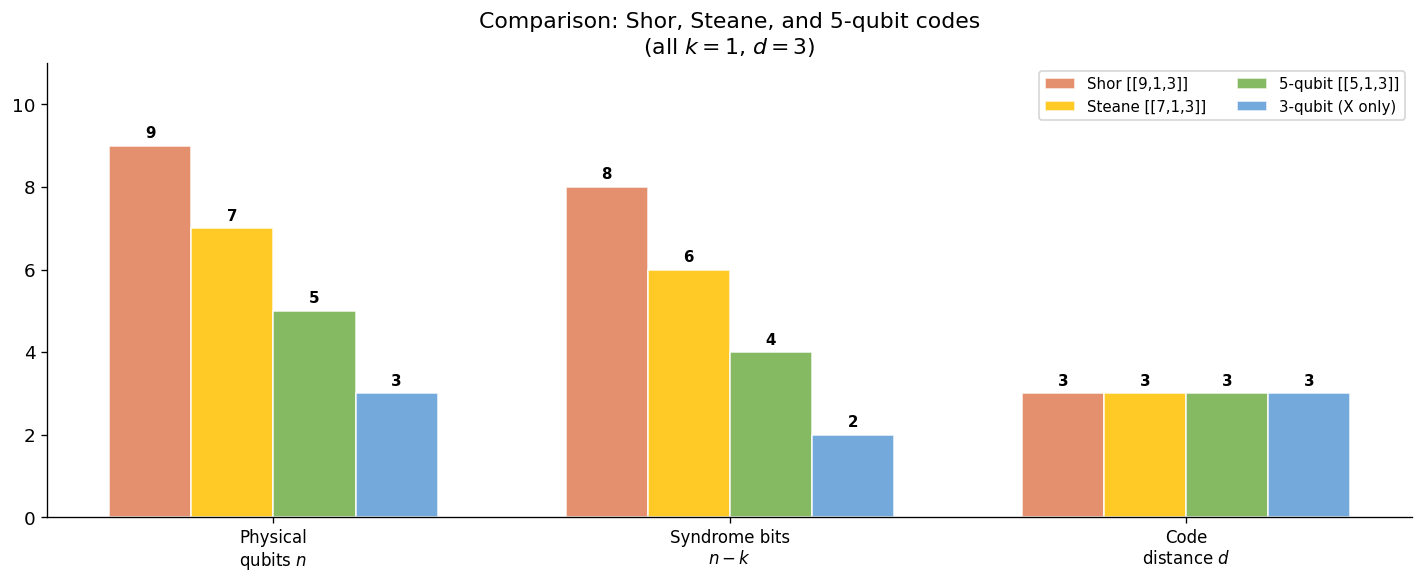

In [6]:
# ── 5-qubit perfect code generators ──────────────────────────────────────────
fivequbit_generators = [
    'XZZXI',   # g1
    'IXZZX',   # g2
    'XIXZZ',   # g3
    'ZXIXZ',   # g4
]

print("=== [[5,1,3]] Perfect Code ===")
print("Stabilizer generators (cyclic pattern XZZXI):")
for i, g in enumerate(fivequbit_generators, 1):
    print(f"  g{i} = {g}")

# Verify cyclic symmetry
def cyclic_shift(s: str) -> str:
    return s[-1] + s[:-1]

print("\nCyclic symmetry check:")
print(f"  g1 = {fivequbit_generators[0]}")
for i in range(1, 4):
    shifted = cyclic_shift(fivequbit_generators[i-1])
    match = shifted == fivequbit_generators[i]
    print(f"  shift(g{i}) = {shifted} == g{i+1}? {match}")

# Verify all pairs commute
all_com5 = True
for i in range(4):
    for j in range(i+1, 4):
        if not commutes(fivequbit_generators[i], fivequbit_generators[j]):
            print(f"  ERROR: g{i+1} and g{j+1} anticommute!")
            all_com5 = False
print(f"\nAll generator pairs commute: {all_com5} ✓")

# ── Full syndrome table for all 15 single-qubit errors ────────────────────────
print("\n=== Full syndrome table [[5,1,3]] code ===")
print(f"{'Error':>8} | {'Syndrome':>8} | {'Unique?':>8}")
print("-" * 32)

syndromes_seen = {}
all_unique = True
print(f"{'None':>8} | {'0000':>8} | {'—':>8}")
syndromes_seen['0000'] = 'None'

for q in range(5):
    for p in ['X', 'Z', 'Y']:
        err = 'I'*q + p + 'I'*(4-q)
        syn = syndrome(err, fivequbit_generators)
        syn_str = ''.join(map(str, syn))
        unique = syn_str not in syndromes_seen
        if not unique:
            all_unique = False
        syndromes_seen[syn_str] = err
        print(f"{'q'+str(q)+p:>8} | {syn_str:>8} | {'✓' if unique else '✗ CLASH':>8}")

print(f"\nAll 15 single-qubit error syndromes are unique: {all_unique}")
print(f"Total distinct syndromes used: {len(syndromes_seen)-1}/15 of 2^4-1=15 available")
print("→ Perfect code: syndrome space is exactly filled!")


# ── 5-qubit encoding circuit ──────────────────────────────────────────────────
def fivequbit_encoding_circuit() -> QuantumCircuit:
    """
    [[5,1,3]] perfect code encoding circuit.
    Logical qubit: q0. Physical: q0..q4.
    Based on: Gottesman, PhD thesis (1997), Table 2.
    """
    qc = QuantumCircuit(5, name='5qubit_encode')
    qc.h(0)
    qc.cz(0, 1); qc.cz(0, 2); qc.cz(0, 3); qc.cz(0, 4)
    qc.h(1); qc.h(2); qc.h(3); qc.h(4)
    qc.cx(0, 1); qc.cx(0, 2); qc.cx(0, 3); qc.cx(0, 4)
    qc.s(0); qc.s(1); qc.s(2); qc.s(3); qc.s(4)
    return qc

qc5 = fivequbit_encoding_circuit()
print(f"\n5-qubit encoding circuit:")
print(qc5.draw(output='text', fold=100))

# ── Side-by-side grouped comparison: Shor vs Steane vs 5-qubit ───────────────
comparison_data = {
    'Physical\nqubits $n$':  [9, 7, 5, 3],
    'Syndrome bits\n$n-k$':  [8, 6, 4, 2],
    'Code\ndistance $d$':    [3, 3, 3, 3],
}
codes_names  = ['Shor [[9,1,3]]', 'Steane [[7,1,3]]', '5-qubit [[5,1,3]]', '3-qubit (X only)']
colors_comp  = ['#e07b54', '#ffc000', '#70ad47', '#5b9bd5']

metrics  = list(comparison_data.keys())
n_codes  = len(codes_names)
bar_w    = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics))

for j, (code, col) in enumerate(zip(codes_names, colors_comp)):
    # offset each code's bar symmetrically around the group centre
    offset = (j - (n_codes - 1) / 2) * bar_w
    vals   = [comparison_data[m][j] for m in metrics]
    bars   = ax.bar(x + offset, vals, bar_w,
                    label=code, color=col, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.12,
                str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_title("Comparison: Shor, Steane, and 5-qubit codes\n(all $k=1$, $d=3$)")
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0, 11)
plt.tight_layout()
plt.show()

---
## 2.7 The Surface Code $[[d^2, 1, d]]$ and Toric Code

> **↗ Cross-reference:** The full treatment of the surface code, including:
> - Rotated surface code lattice (d=3,5,7) with `stim`
> - Detector error models and Monte Carlo threshold simulations
> - MWPM decoding with `pymatching`
> - Logical error rate scaling $p_L \sim (p/p_{\text{th}})^{(d+1)/2}$
> - Lattice surgery for logical gates
> - Threshold $p_{\text{th}} \approx 1\%$
>
> is covered in full in:
>
> **[`surface_code_tutorial.ipynb`](./surface_code_tutorial.ipynb)**

### Summary and theory

The **toric code** (Kitaev, 1997 [7]) is defined on an $L \times L$ square lattice
with periodic boundary conditions. **Data qubits** sit on edges; **ancilla qubits**
measure plaquette and vertex operators.

**Stabilizer generators** of the toric code:
- **Vertex operators** ($X$-type): $A_v = \prod_{e \in \partial v} X_e$ (product over edges touching vertex $v$)
- **Plaquette operators** ($Z$-type): $B_p = \prod_{e \in \partial p} Z_e$ (product over edges bounding face $p$)

All $A_v$ commute with all $B_p$ because each plaquette shares an even number of
edges with each vertex (0 or 2). This is the **topological** reason for the code's
stability.

The **planar (rotated) surface code** is the open-boundary version:
$$[[n, k, d]] = [[d^2, 1, d]] \quad \text{(rotated layout)}, \qquad
[[2d^2-1, 1, d]] \quad \text{(standard layout)}$$

**Key properties:**
- Threshold $p_{\text{th}} \approx 1\%$ under depolarizing noise (extremely high)
- Local 2D interactions only (natural for superconducting architectures)
- Logical error rate below threshold: $p_L \approx A(p/p_{\text{th}})^{(d+1)/2}$
- Google Quantum AI demonstrated below-threshold scaling in 2023 (Nature **614**, 676–681)

**Logical operators** are non-contractible paths across the lattice:
$$\bar{X} = \prod_{e \in \gamma_X} X_e \quad (\text{horizontal path})$$
$$\bar{Z} = \prod_{e \in \gamma_Z} Z_e \quad (\text{vertical path})$$

Both have weight $d$ (the path crosses $d$ edges), so the code distance equals $d$.

> See `surface_code_tutorial.ipynb` for the stim + pymatching simulation code,
> threshold plots, and lattice surgery CNOT implementations.

Also related: **`ising_surface_code_qec.ipynb`** and **`cliff_trott_ising.ipynb`**
in this repository apply surface code ideas to the Trotterized Ising model as a
quantum error benchmarking testbed.

---
## 2.8 Bosonic Codes — GKP and Cat Codes

All codes in Sections 2.3–2.7 encode logical qubits in **multi-qubit systems**.
Bosonic codes take a fundamentally different approach: they encode a single logical qubit
in a **single bosonic mode** (a quantum harmonic oscillator — a microwave cavity, an
optical mode, or a motional mode of a trapped ion).

A bosonic mode has infinitely many energy levels $|0\rangle, |1\rangle, |2\rangle, \ldots$,
which provides the extra Hilbert space dimensions needed for redundancy.

### 2.8.1 The harmonic oscillator

The bosonic mode is described by the ladder operators:

$$a|n\rangle = \sqrt{n}|n-1\rangle, \qquad a^\dagger|n\rangle = \sqrt{n+1}|n+1\rangle$$

$$\hat{n} = a^\dagger a, \quad [a, a^\dagger] = 1$$

The **quadrature operators** (position and momentum in phase space):

$$\hat{q} = \frac{a + a^\dagger}{\sqrt{2}}, \qquad \hat{p} = \frac{a - a^\dagger}{i\sqrt{2}}$$

satisfy $[\hat{q}, \hat{p}] = i$.

### 2.8.2 GKP code (Gottesman–Kitaev–Preskill)

The GKP code [9] encodes a qubit in the **position-space grid** structure of the oscillator.

**Stabilizers** (displacement operators):
$$S_q = e^{i 2\sqrt{\pi} \hat{q}}, \qquad S_p = e^{-i 2\sqrt{\pi} \hat{p}}$$

These are the displacements by $2\sqrt{\pi}$ in position and momentum respectively.

**Logical codewords** (ideal, non-normalizable):
$$|0\rangle_L \propto \sum_{n \in \mathbb{Z}} |q = 2n\sqrt{\pi}\rangle, \qquad
|1\rangle_L \propto \sum_{n \in \mathbb{Z}} |q = (2n+1)\sqrt{\pi}\rangle$$

In phase space, these are **grids of delta functions** at even and odd multiples of $\sqrt{\pi}$.

**Logical operators:**
$$\bar{X} = e^{i\sqrt{\pi}\hat{q}}, \qquad \bar{Z} = e^{-i\sqrt{\pi}\hat{p}}$$

**Error correction:** A small displacement error $D(\xi) = e^{(\xi a^\dagger - \xi^* a)}$
shifts the grid by $\xi$. The syndrome measurement (homodyne detection mod $\sqrt{\pi}$)
reveals the fractional shift without disturbing the logical state. Errors are correctable
as long as $|\text{Re}(\xi)|, |\text{Im}(\xi)| < \sqrt{\pi}/2$.

**Practical implementation:** Oscillators can be microwave cavities (circuit QED) or
phonon modes (trapped ion). Recent experiments (Campagne-Ibarcq et al., Nature 2020)
achieved below-breakeven lifetime for GKP qubits.

### 2.8.3 Cat codes (Kerr cat qubit)

The **cat code** [10] encodes a logical qubit in the two coherent states $|\alpha\rangle$
and $|-\alpha\rangle$ (Schrödinger cat states):

$$|0\rangle_L = \mathcal{N}_+(|\alpha\rangle + |-\alpha\rangle), \qquad
|1\rangle_L = \mathcal{N}_-(|\alpha\rangle - |-\alpha\rangle)$$

where $\mathcal{N}_\pm$ are normalisation constants.

**Why cat states?** A **Kerr oscillator** with Hamiltonian
$H_K = -K (a^\dagger)^2 a^2$ naturally stabilises these states.
Two-photon pumping with $H_\epsilon = \epsilon_2 (a^\dagger)^2 + \text{h.c.}$
confines the state to a manifold spanned by $|\pm\alpha\rangle$ where
$|\alpha|^2 = \epsilon_2/K$.

**Noise bias:** The dominant error is **phase flips** ($\bar{Z}$ errors) proportional
to $e^{-2|\alpha|^2}$, while **bit flips** ($\bar{X}$ errors) are exponentially suppressed
in $|\alpha|^2$. For $|\alpha|^2 \sim 4$, the bit-flip rate is $\sim 10^{-3}$
smaller than the phase-flip rate.

This **biased noise** is exploited by pairing the cat qubit with a repetition code
(which naturally corrects the dominant phase-flip errors), achieving high threshold
with far fewer physical modes than a surface code.

C:\Users\tan\AppData\Local\Temp\ipykernel_1396\1340381453.py:90: RuntimeWarning: invalid value encountered in divide
  cat1 = p - m; cat1 /= np.linalg.norm(cat1)


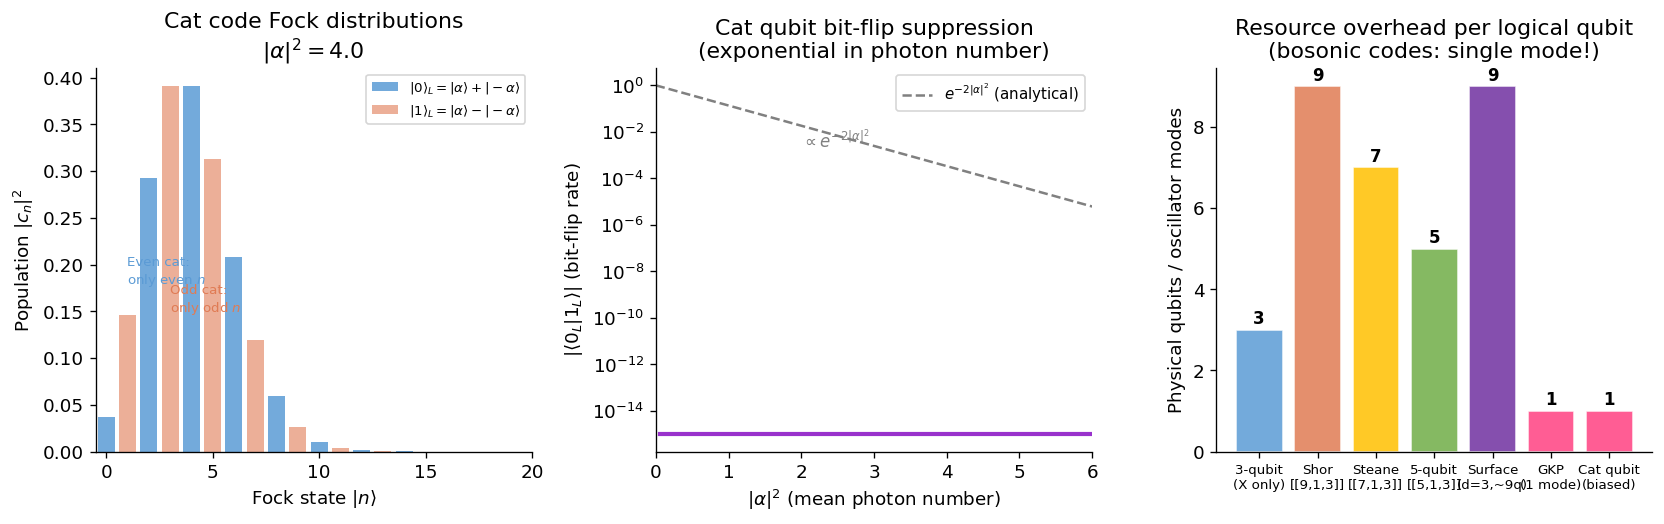

Key takeaways:
  Cat code: bit-flip probability ∝ exp(-2|α|²) — exponentially suppressed.
  Even/odd cat states occupy orthogonal Fock-number parity subspaces.
  GKP and cat codes reduce overhead to 1 physical mode per logical qubit,
  at the cost of more complex hardware (cavities, Kerr interactions).


In [7]:
# ── Wigner function helper ────────────────────────────────────────────────────
import math

# ── Cat state: |α⟩ + |-α⟩ in Fock basis ─────────────────────────────────────
def coherent_fock(alpha, N=30):
    """Coherent state |α⟩ in truncated Fock basis."""
    from scipy.special import factorial
    n_arr = np.arange(N)
    coeffs = (np.exp(-abs(alpha)**2/2) *
              alpha**n_arr / np.sqrt(factorial(n_arr)))
    return coeffs / np.linalg.norm(coeffs)

def wigner_fock(rho, xvec, pvec):
    """
    Wigner function W(q,p) of a density matrix in the Fock basis.
    Uses the Laguerre polynomial formula (Cahill & Glauber 1969):

        W(α) = (2/π) Σ_{n} (-1)^n ⟨n| D(-α) ρ D(α) |n⟩

    where α = (q + ip)/√2 and D(α) is the displacement operator.
    This implementation uses the Fock-matrix element formula:

        W(α) = (2/π) e^{-2|α|²} Σ_{n,m} ρ_{nm} L^{n-m}_{m}(4|α|²) (...)

    For pedagogical purposes we use the direct coherent-state overlap method,
    which is exact in the truncated Fock space and avoids scipy's polygamma.

    Reference: Cahill & Glauber, Phys. Rev. 177, 1882 (1969).
    """
    N   = rho.shape[0]
    W   = np.zeros((len(pvec), len(xvec)))

    for ip, p in enumerate(pvec):
        for iq, q in enumerate(xvec):
            alpha = (q + 1j * p) / np.sqrt(2)
            # Fock amplitudes of coherent state |α⟩
            n_arr   = np.arange(N)
            amp     = (np.exp(-0.5 * abs(alpha)**2) *
                       alpha**n_arr /
                       np.sqrt(np.array([math.factorial(int(n)) for n in n_arr],
                                        dtype=float)))
            norm_sq = np.dot(amp.conj(), amp).real
            if norm_sq > 0:
                amp /= np.sqrt(norm_sq)
            W[ip, iq] = np.real(amp.conj() @ rho @ amp)

    return (2 / np.pi) * W

N_fock = 30
alpha_val = 2.0

psi_plus_cat  = coherent_fock( alpha_val, N_fock)
psi_minus_cat = coherent_fock(-alpha_val, N_fock)

# Even cat (|0⟩_L) and odd cat (|1⟩_L)
psi_cat0 = (psi_plus_cat + psi_minus_cat)
psi_cat0 /= np.linalg.norm(psi_cat0)
psi_cat1 = (psi_plus_cat - psi_minus_cat)
psi_cat1 /= np.linalg.norm(psi_cat1)

rho_cat0 = np.outer(psi_cat0, psi_cat0.conj())
rho_cat1 = np.outer(psi_cat1, psi_cat1.conj())

# ── Photon number distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

n_arr = np.arange(N_fock)

ax = axes[0]
ax.bar(n_arr, np.abs(psi_cat0)**2, color='#5b9bd5', alpha=0.85,
       label=r'$|0\rangle_L = |\alpha\rangle + |-\alpha\rangle$')
ax.bar(n_arr, np.abs(psi_cat1)**2, color='#e07b54', alpha=0.6,
       label=r'$|1\rangle_L = |\alpha\rangle - |-\alpha\rangle$')
ax.set_xlabel('Fock state $|n\\rangle$')
ax.set_ylabel('Population $|c_n|^2$')
ax.set_title(f'Cat code Fock distributions\n$|\\alpha|^2 = {alpha_val**2:.1f}$')
ax.legend(fontsize=8)
ax.set_xlim(-0.5, 20)
ax.text(1, 0.18, 'Even cat:\nonly even $n$', fontsize=8, color='#5b9bd5')
ax.text(3, 0.15, 'Odd cat:\nonly odd $n$', fontsize=8, color='#e07b54')

# ── Overlap between |0_L⟩ and |1_L⟩ (bit-flip suppression) ──────────────────
alphas_sq = np.linspace(0, 6, 100)
overlaps = []
for a2 in alphas_sq:
    a = np.sqrt(a2)
    p = coherent_fock(a, N_fock)
    m = coherent_fock(-a, N_fock)
    cat0 = p + m; cat0 /= np.linalg.norm(cat0)
    cat1 = p - m; cat1 /= np.linalg.norm(cat1)
    overlaps.append(abs(cat0.conj() @ cat1))

ax2 = axes[1]
ax2.semilogy(alphas_sq, np.array(overlaps) + 1e-15, color='darkorchid', linewidth=2.5)
ax2.semilogy(alphas_sq, np.exp(-2*alphas_sq), '--', color='gray',
             linewidth=1.5, label=r'$e^{-2|\alpha|^2}$ (analytical)')
ax2.set_xlabel('$|\\alpha|^2$ (mean photon number)')
ax2.set_ylabel(r'$|\langle 0_L | 1_L \rangle|$ (bit-flip rate)')
ax2.set_title('Cat qubit bit-flip suppression\n(exponential in photon number)')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 6)
ax2.text(2, 2e-3, r'$\propto e^{-2|\alpha|^2}$', fontsize=10, color='gray')

# ── Code comparison: qubit count or mode overhead ─────────────────────────────
ax3 = axes[2]
data_comp = {
    '3-qubit\n(X only)':  3,
    'Shor\n[[9,1,3]]':    9,
    'Steane\n[[7,1,3]]':  7,
    '5-qubit\n[[5,1,3]]': 5,
    'Surface\n(d=3,~9q)': 9,
    'GKP\n(1 mode)':      1,
    'Cat qubit\n(biased)': 1,
}
names3 = list(data_comp.keys())
vals3  = list(data_comp.values())
cols3  = ['#5b9bd5','#e07b54','#ffc000','#70ad47','#7030a0','#ff4081','#ff4081']
bars3  = ax3.bar(names3, vals3, color=cols3, alpha=0.85, edgecolor='white')
ax3.set_ylabel('Physical qubits / oscillator modes')
ax3.set_title('Resource overhead per logical qubit\n(bosonic codes: single mode!)')
for bar, v in zip(bars3, vals3):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.05, str(v),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

print("Key takeaways:")
print("  Cat code: bit-flip probability ∝ exp(-2|α|²) — exponentially suppressed.")
print("  Even/odd cat states occupy orthogonal Fock-number parity subspaces.")
print("  GKP and cat codes reduce overhead to 1 physical mode per logical qubit,")
print("  at the cost of more complex hardware (cavities, Kerr interactions).")

---
## 2.9 Error Mitigation: ZNE and PEC

Unlike QEC, **error mitigation** does not protect the quantum state during computation.
Instead, it post-processes measurement results on noisy hardware to obtain better
estimates of expectation values, without any qubit overhead.

This makes it practical for NISQ (Noisy Intermediate-Scale Quantum) devices, which
have too few qubits and too high error rates for full QEC.

> **Reference:** The Mitiq library provides production-ready implementations of all
> methods described here. See:  
> https://mitiq.readthedocs.io/en/stable/guide/error-mitigation.html

### 2.9.1 Zero-Noise Extrapolation (ZNE)

**Idea:** Run the circuit at several noise levels $\lambda_1 < \lambda_2 < \ldots$,
measure $\langle O \rangle_{\lambda_i}$, then **extrapolate** to $\lambda \to 0$.

**Noise scaling:** The noise level is amplified by:
1. **Gate folding**: replace each gate $G$ with $G \cdot G^\dagger \cdot G$
   (identity logically, but 3× the noise). Fold $m$ gates to get noise level $2m+1$.
2. **Pulse stretching**: slow down the physical pulses by factor $\lambda$.

**Extrapolation models:**

*Linear extrapolation (Richardson, 1 step):*
$$\langle O \rangle_0 \approx \frac{\lambda_2 \langle O\rangle_1 - \lambda_1 \langle O\rangle_2}{\lambda_2 - \lambda_1}$$

*Polynomial extrapolation (order $p$):*
$$\langle O \rangle_{\lambda} = \sum_{k=0}^{p} a_k \lambda^k \quad \Rightarrow \quad \langle O \rangle_0 = a_0$$

*Exponential extrapolation:*
$$\langle O \rangle_\lambda = A e^{-B\lambda} + C \quad \Rightarrow \quad \langle O\rangle_0 = A + C$$

**Error analysis:** ZNE reduces the bias at the cost of increased variance.
For a Richardson extrapolation with $m$ noise levels, the variance scales as $O(m^2)$
relative to a single-level measurement. Always check that the signal-to-noise is
sufficient before applying high-order ZNE.

**Reference:** Temme, Li, Benjamin [11,12].

### 2.9.2 Probabilistic Error Cancellation (PEC)

**Idea:** Express the ideal (noiseless) channel $\mathcal{U}$ as a quasi-probability
decomposition over implementable noisy operations $\{\mathcal{O}_i\}$:

$$\mathcal{U}(\rho) = \sum_i \gamma_i \mathcal{O}_i(\rho), \quad \gamma_i \in \mathbb{R},
\quad \sum_i |\gamma_i| = \gamma_1^{\text{tot}}$$

**Sampling:** Draw operations $\mathcal{O}_i$ according to $|\gamma_i|/\gamma_1^{\text{tot}}$,
run them, and weight each outcome by $\text{sign}(\gamma_i) \cdot \gamma_1^{\text{tot}}$.

The unbiased estimator is:
$$\langle O \rangle_{\text{ideal}} \approx \frac{\gamma_1^{\text{tot}}}{N_{\text{shots}}}
\sum_k \text{sign}(\gamma_{i_k}) O_k$$

**Sampling overhead:** The variance scales as $\gamma_1^{\text{tot}}^2$ — exponential
in circuit depth for a depolarizing channel with error rate $p$:
$$\gamma_1^{\text{tot}} = \prod_{\text{gates}} (1 + 2p_g) \approx e^{2\sum_g p_g}$$

PEC is thus exact (unbiased) but requires exponentially more samples for deep circuits.
For shallow NISQ circuits it is practical.

**Reference:** van den Berg et al., Nature Physics 2023 (experimental PEC on 119 qubits).

### 2.9.3 When to use QEC vs mitigation

| Feature | QEC | ZNE | PEC |
|---|---|---|---|
| Qubit overhead | $O(d^2)$–$O(n)$ extra qubits | None | None |
| Shot overhead | None | $O(1)$–$O(m^2)$ | $O(e^{2\epsilon n})$ exponential |
| Error threshold | Requires $p < p_{\text{th}}$ | Works for any $p$ | Works for any $p$ |
| Protects quantum state | Yes | No | No |
| Useful regime | Fault-tolerant QC (future) | NISQ, $n \leq 100$ | NISQ, shallow circuits |

=== ZNE demonstration: ⟨X⟩ for |+⟩ state under depolarizing noise ===
Ideal ⟨X⟩ = 1.0,  depolarizing rate p = 0.05

  fold_factor = 1  (noise ≈ 1×p = 0.050):  ⟨X⟩ = 0.9028
  fold_factor = 3  (noise ≈ 3×p = 0.150):  ⟨X⟩ = 0.8130
  fold_factor = 5  (noise ≈ 5×p = 0.250):  ⟨X⟩ = 0.7437
  fold_factor = 7  (noise ≈ 7×p = 0.350):  ⟨X⟩ = 0.6606

Extrapolation fits (estimating ⟨X⟩ at λ → 0):
  Order-1 polynomial:  ⟨X⟩₀ ≈ 0.9478  (error = 0.0522)
  Order-2 polynomial:  ⟨X⟩₀ ≈ 0.9554  (error = 0.0446)
  Order-3 polynomial:  ⟨X⟩₀ ≈ 0.9661  (error = 0.0339)
  Exponential fit:       ⟨X⟩₀ ≈ 0.9442  (error = 0.0558)


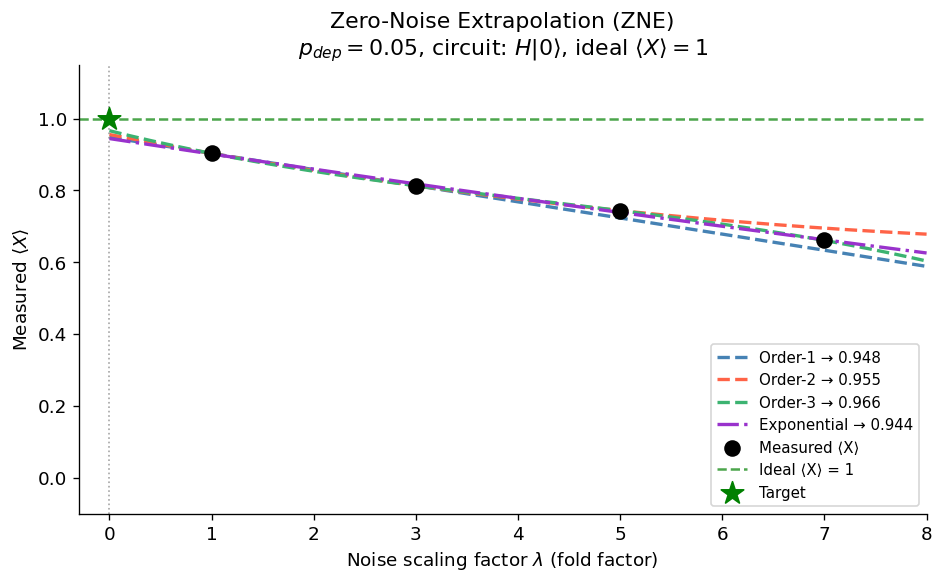


Key result:
  Raw noisy ⟨X⟩ at λ=1:  0.9028  (bias = 0.0972)
  ZNE reduces bias at the cost of increased shot-noise variance.


In [8]:
# ── ZNE from scratch: noise amplification via gate folding ───────────────────
# We demonstrate ZNE on a simple circuit: prepare |+⟩ and measure ⟨X⟩.
# Ideal value: ⟨X⟩ = 1. Noisy value < 1 due to depolarizing noise.
#
# Reference: Temme et al., PRL 119, 180509 (2017).

def fold_gates(qc: QuantumCircuit, fold_factor: int) -> QuantumCircuit:
    """
    Gate-folding noise amplification.
      fold_factor = 1: original circuit (no folding)
      fold_factor = 3: G → G G† G  (3× noise per gate)
      fold_factor = 5: G → G G† G G† G  (5× noise per gate)
    Only odd fold_factors preserve the logical unitary.

    Qiskit 1.x compatible: always use explicit (operation, qubits, clbits).
    """
    if fold_factor == 1:
        return qc.copy()
    if fold_factor % 2 == 0:
        raise ValueError("fold_factor must be odd (1, 3, 5, …)")

    qc_folded = QuantumCircuit(*qc.qregs)   # same qubit registers, no classical
    for inst in qc.data:
        op, qargs, cargs = inst.operation, inst.qubits, inst.clbits
        qc_folded.append(op, qargs, cargs)                    # G
        for _ in range((fold_factor - 1) // 2):
            qc_folded.append(op.inverse(), qargs, cargs)      # G†
            qc_folded.append(op, qargs, cargs)                # G
    return qc_folded


def measure_expectation_X(qc_base: QuantumCircuit,
                           p_dep: float,
                           fold_factor: int = 1,
                           n_shots: int = 8192) -> float:
    """
    Fold qc_base, apply depolarizing noise, measure ⟨X⟩ on qubit 0.
    X-basis expectation: apply H then measure in Z basis.
    ⟨X⟩ = P(0) - P(1).
    """
    qc_folded = fold_gates(qc_base, fold_factor)

    qc_meas = qc_folded.copy()
    qc_meas.h(0)           # rotate to X basis
    qc_meas.measure_all()

    # ── Noise model: single-qubit depolarizing on all 1-qubit gates ──────────
    # Only add 1-qubit errors to 1-qubit gates; cx would need depolarizing_error(p,2)
    one_qubit_gates = ['h', 'x', 'y', 'z', 's', 'sdg', 'rz', 'sx', 'id']
    nm = NoiseModel()
    for gate in one_qubit_gates:
        nm.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), [gate])

    sim    = AerSimulator(noise_model=nm)
    result = sim.run(transpile(qc_meas, sim, optimization_level=0),
                     shots=n_shots).result()
    counts = result.get_counts()

    # Qiskit counts keys: qubit 0 is the rightmost character
    p0 = sum(v for k, v in counts.items() if k[-1] == '0') / n_shots
    return 2 * p0 - 1


# ── Circuit: H gate on 1 qubit ────────────────────────────────────────────────
qc_base = QuantumCircuit(1)
qc_base.h(0)

p_dep        = 0.05   # 5% per gate — strong noise so the trend is visible
fold_factors = [1, 3, 5, 7]

print("=== ZNE demonstration: ⟨X⟩ for |+⟩ state under depolarizing noise ===")
print(f"Ideal ⟨X⟩ = 1.0,  depolarizing rate p = {p_dep}\n")

n_shots      = 8192
expectations = []
for ff in fold_factors:
    val = measure_expectation_X(qc_base, p_dep, fold_factor=ff, n_shots=n_shots)
    expectations.append(val)
    print(f"  fold_factor = {ff}  (noise ≈ {ff}×p = {ff*p_dep:.3f}):  ⟨X⟩ = {val:.4f}")

# ── Extrapolation to zero noise ────────────────────────────────────────────────
from scipy.optimize import curve_fit

lambda_arr = np.array(fold_factors, dtype=float)
exp_arr    = np.array(expectations)
lambda_fine = np.linspace(0, 8, 200)

print("\nExtrapolation fits (estimating ⟨X⟩ at λ → 0):")
fig, ax = plt.subplots(figsize=(8, 5))
colors_zne = ['steelblue', 'tomato', 'mediumseagreen']

for order, col in zip([1, 2, 3], colors_zne):
    if order + 1 > len(fold_factors):
        break
    coeffs     = np.polyfit(lambda_arr[:order+1], exp_arr[:order+1], order)
    poly       = np.poly1d(coeffs)
    extrap_val = float(poly(0))
    print(f"  Order-{order} polynomial:  ⟨X⟩₀ ≈ {extrap_val:.4f}  "
          f"(error = {abs(extrap_val - 1.0):.4f})")
    ax.plot(lambda_fine, poly(lambda_fine), '--', color=col, linewidth=2,
            label=f'Order-{order} → {extrap_val:.3f}')

# Exponential fit using all four points
try:
    def exp_model(lam, A, B, C): return A * np.exp(-B * lam) + C
    popt, _ = curve_fit(exp_model, lambda_arr, exp_arr, p0=[0.5, 0.1, 0.5])
    extrap_exp = float(popt[0] + popt[2])
    print(f"  Exponential fit:       ⟨X⟩₀ ≈ {extrap_exp:.4f}  "
          f"(error = {abs(extrap_exp - 1.0):.4f})")
    ax.plot(lambda_fine, exp_model(lambda_fine, *popt), '-.',
            color='darkorchid', linewidth=2,
            label=f'Exponential → {extrap_exp:.3f}')
except Exception as e:
    print(f"  Exponential fit failed: {e}")

ax.scatter(lambda_arr, exp_arr, zorder=5, s=80, color='black', label='Measured ⟨X⟩')
ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Ideal ⟨X⟩ = 1')
ax.scatter([0], [1.0], marker='*', s=200, color='green', zorder=10, label='Target')

ax.set_xlabel('Noise scaling factor $\\lambda$ (fold factor)')
ax.set_ylabel('Measured $\\langle X \\rangle$')
ax.set_title(f'Zero-Noise Extrapolation (ZNE)\n'
             f'$p_{{dep}} = {p_dep}$, circuit: $H|0\\rangle$, ideal $\\langle X\\rangle = 1$')
ax.legend(fontsize=9)
ax.set_xlim(-0.3, 8)
ax.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

print(f"\nKey result:")
print(f"  Raw noisy ⟨X⟩ at λ=1:  {expectations[0]:.4f}  (bias = {1-expectations[0]:.4f})")
print(f"  ZNE reduces bias at the cost of increased shot-noise variance.")

=== PEC Quasi-Probability Decomposition ===

   p_dep |      γ_I |  γ_X=γ_Y=γ_Z |   γ₁ total |   Overhead γ₁²
------------------------------------------------------------
   0.001 |  1.00100 |     -0.00033 |    1.00200 |        1.00401
   0.005 |  1.00503 |     -0.00168 |    1.01007 |        1.02024
   0.010 |  1.01014 |     -0.00338 |    1.02027 |        1.04095
   0.020 |  1.02055 |     -0.00685 |    1.04110 |        1.08388
   0.050 |  1.05357 |     -0.01786 |    1.10714 |        1.22577
   0.100 |  1.11538 |     -0.03846 |    1.23077 |        1.51479


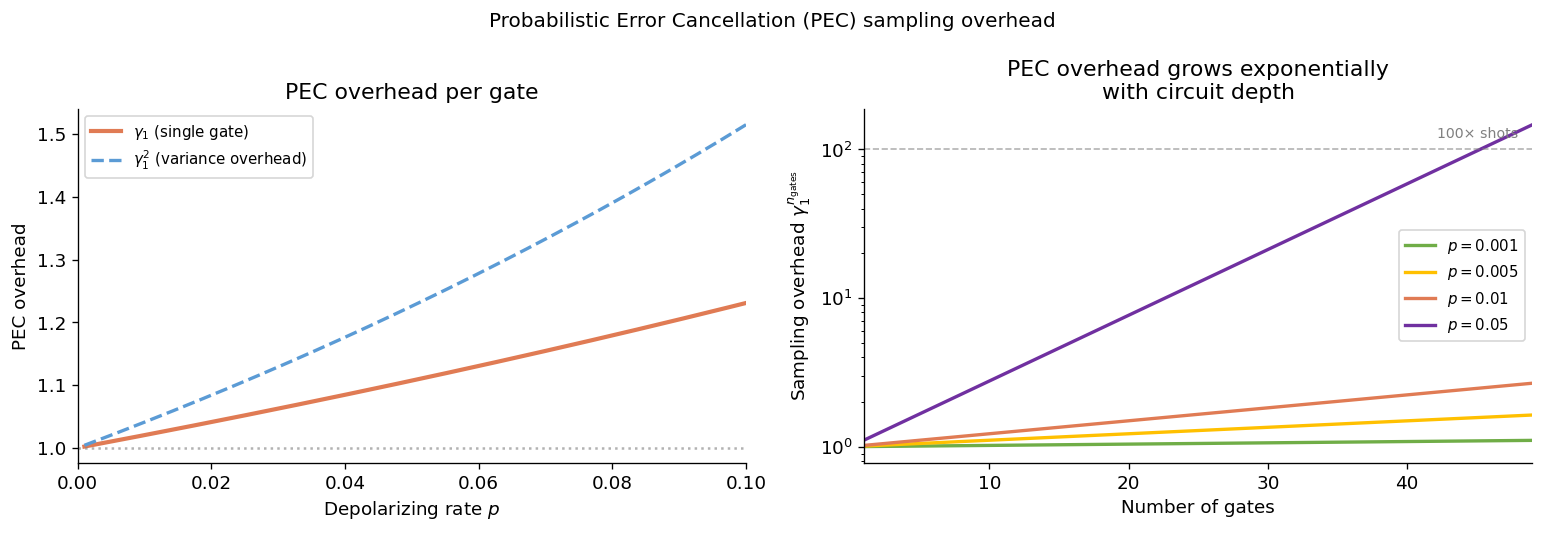


Key conclusions:
  ZNE: zero qubit overhead, polynomial shot overhead, works for deep circuits.
  PEC: unbiased, but exponential shot overhead → practical only for short circuits.
  Both are error MITIGATION (improve expectation values) not error CORRECTION
  (do not protect the quantum state).


In [12]:
# ── PEC: quasi-probability decomposition for depolarizing noise ───────────────
#
# For a single depolarizing gate with error probability p:
#   E(ρ) = (1-p)ρ + (p/3)(XρX + YρY + ZρZ)
#
# The ideal channel U(ρ) = the gate applied to ρ.
#
# The inverse channel that 'undoes' the noise:
#   U_ideal = E^{-1} ∘ E_noisy
#
# For a depolarizing channel: E^{-1}(ρ) = (1+p')ρ - (p'/3)(XρX + YρY + ZρZ)
# where p' = p/(1 - 4p/3)
#
# The quasi-probability decomposition of the ideal operation:
#   U_ideal(ρ) = γ⁺ · O₁(ρ) - γ⁻ · O₂(ρ) - ...
# where Oᵢ are implementable operations (noisy gates ∘ Pauli corrections)

def pec_overhead(p_dep: float) -> tuple:
    """
    Compute the PEC sampling overhead γ₁ for a single depolarizing gate.
    Returns (gamma_1_total, coefficients_dict).
    """
    # Quasi-prob: α_I = (1-p)/(1-4p/3), α_X = α_Y = α_Z = -p/(3(1-4p/3))...
    # More precisely: γ_i are the abs sum of quasi-probs
    # For a single-qubit depolarizing channel with param p:
    # Inverse: E^{-1}(ρ) = c_I * ρ + c_X * XρX + c_Y * YρY + c_Z * ZρZ
    # Solve: E ∘ E^{-1} = I
    # c_I + c_X + c_Y + c_Z = 1  (trace preservation)
    # c_I - c_X/3 - c_Y/3 - c_Z/3 = 1/(1-4p/3)  (from Bloch sphere map)
    # By symmetry: c_X = c_Y = c_Z
    # (1-p)c_I + 3*(p/3)*c_X = 1  → c_I(1-p) + p*c_X = 1
    # c_I + 3c_X = 1 (trace preservation)
    # Solving:
    # One-qubit depolarizing channel E maps ρ → (1-4p/3)ρ + (p/3)·I
    # For the Bloch vector: r → (1-4p/3)r
    # Inverse: r → r/(1-4p/3)
    # As a Pauli channel: E^{-1}(ρ) = γ_0 I ρ I + γ_1 X ρ X + ...
    # where Σγ_i = 1 (quasi-probs) but some γ_i < 0

    if 4*p_dep/3 >= 1:
        raise ValueError("p_dep too large (≥ 3/4): channel not invertible")

    q = p_dep / (1 - 4*p_dep/3)   # re-scaled parameter
    c_I = 1 + q
    c_P = -q / 3   # for each of X, Y, Z

    gamma_1 = abs(c_I) + 3*abs(c_P)  # L1 norm of quasi-probs

    return gamma_1, {'I': c_I, 'X': c_P, 'Y': c_P, 'Z': c_P}


print("=== PEC Quasi-Probability Decomposition ===\n")
print(f"{'p_dep':>8} | {'γ_I':>8} | {'γ_X=γ_Y=γ_Z':>12} | {'γ₁ total':>10} | {'Overhead γ₁²':>14}")
print("-" * 60)
for p in [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]:
    try:
        g1, coeffs = pec_overhead(p)
        print(f"{p:>8.3f} | {coeffs['I']:>8.5f} | {coeffs['X']:>12.5f} | "
              f"{g1:>10.5f} | {g1**2:>14.5f}")
    except ValueError as e:
        print(f"{p:>8.3f} | {'—':>8} | {'—':>12} | {str(e):>10}")


# ── PEC overhead scaling plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

p_arr = np.linspace(0.001, 0.1, 300)
gamma1_arr = []
for p in p_arr:
    try:
        g1, _ = pec_overhead(p)
        gamma1_arr.append(g1)
    except ValueError:
        gamma1_arr.append(np.nan)
gamma1_arr = np.array(gamma1_arr)

ax1 = axes[0]
ax1.plot(p_arr, gamma1_arr, color='#e07b54', linewidth=2.5,
         label=r'$\gamma_1$ (single gate)')
ax1.plot(p_arr, gamma1_arr**2, '--', color='#5b9bd5', linewidth=2,
         label=r'$\gamma_1^2$ (variance overhead)')
ax1.set_xlabel('Depolarizing rate $p$')
ax1.set_ylabel('PEC overhead')
ax1.set_title('PEC overhead per gate')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 0.1)
ax1.axhline(1, color='gray', linestyle=':', alpha=0.6)

# Multi-gate overhead: γ_tot = γ_1^n_gates (exponential in depth)
ax2 = axes[1]
n_gates_arr = np.arange(1, 50)
for p_val, col in [(0.001, '#70ad47'), (0.005, '#ffc000'), (0.01, '#e07b54'), (0.05, '#7030a0')]:
    g1, _ = pec_overhead(p_val)
    overhead = g1**n_gates_arr
    ax2.semilogy(n_gates_arr, overhead, linewidth=2, color=col,
                 label=f'$p={p_val}$')

ax2.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(48, 120, '100× shots', fontsize=8.5, color='gray', ha='right')
ax2.set_xlabel('Number of gates')
ax2.set_ylabel('Sampling overhead $\\gamma_1^{n_{\\rm gates}}$')
ax2.set_title('PEC overhead grows exponentially\nwith circuit depth')
ax2.legend(fontsize=9)
ax2.set_xlim(1, 49)

plt.suptitle("Probabilistic Error Cancellation (PEC) sampling overhead",
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey conclusions:")
print("  ZNE: zero qubit overhead, polynomial shot overhead, works for deep circuits.")
print("  PEC: unbiased, but exponential shot overhead → practical only for short circuits.")
print("  Both are error MITIGATION (improve expectation values) not error CORRECTION")
print("  (do not protect the quantum state).")

---
## 2.10 Chapter Summary

This chapter presented the complete theoretical and computational landscape of
quantum error correction codes.

**Stabilizer formalism (Section 2.2):**
- Codespace = simultaneous $+1$ eigenspace of stabilizer generators
- Syndrome = binary string indicating which generators anticommute with the error
- Knill–Laflamme conditions determine which error sets are correctable

**Code hierarchy (all correcting 1 error, encoding 1 logical qubit):**

| Code | $n$ | Distance | Type | Best platform |
|---|---|---|---|---|
| 3-qubit (bit-flip) | 3 | 1* | Repetition | Any (educational) |
| Shor | 9 | 3 | Concatenated | First historical code |
| 5-qubit | 5 | 3 | Perfect (saturates Hamming bound) | Any (minimal $n$) |
| Steane | 7 | 3 | CSS (transversal Clifford) | Trapped ion |
| Surface ($d=3$) | 9–17 | 3 | Topological ($p_{\rm th}\sim1\%$) | Superconducting |
| GKP / Cat | 1 mode | — | Bosonic | Microwave cavity |

**Error mitigation vs. error correction:**
- **QEC**: protects the quantum state; requires $p < p_{\rm th}$; qubit overhead $O(d^2)$
- **ZNE**: reduces bias by noise extrapolation; no qubit overhead; polynomial shots
- **PEC**: unbiased estimator via quasi-probabilities; exponential shot overhead

---

## Full References

| # | Reference |
|---|---|
| [1] | Nielsen, M. A. & Chuang, I. L. *Quantum Computation and Quantum Information*. Cambridge, 2010. |
| [2] | Gottesman, D. *Stabilizer Codes and Quantum Error Correction*. PhD thesis, Caltech, 1997. arXiv:quant-ph/9705052 |
| [3] | Calderbank, A. R. & Shor, P. W. Good quantum error-correcting codes exist. *Phys. Rev. A* **54**, 1098 (1996). DOI:10.1103/PhysRevA.54.1098 |
| [4] | Steane, A. M. Multiple particle interference and quantum error correction. *Proc. R. Soc. Lond. A* **452**, 2551 (1996). DOI:10.1098/rspa.1996.0136 |
| [5] | Shor, P. W. Scheme for reducing decoherence in quantum computer memory. *Phys. Rev. A* **52**, R2493 (1995). DOI:10.1103/PhysRevA.52.R2493 |
| [6] | Laflamme, R. et al. Perfect quantum error correcting code. *Phys. Rev. Lett.* **77**, 198 (1996). DOI:10.1103/PhysRevLett.77.198 |
| [7] | Kitaev, A. Yu. Fault-tolerant quantum computation by anyons. *Ann. Phys.* **303**, 2–30 (2003). DOI:10.1016/S0003-4916(02)00018-0 |
| [8] | Fowler, A. M. et al. Surface codes: Towards practical large-scale quantum computation. *Phys. Rev. A* **86**, 032324 (2012). DOI:10.1103/PhysRevA.86.032324 |
| [9] | Gottesman, D., Kitaev, A. & Preskill, J. Encoding a qubit in an oscillator. *Phys. Rev. A* **64**, 012310 (2001). DOI:10.1103/PhysRevA.64.012310 |
| [10] | Grimm, A. et al. Stabilization and operation of a Kerr-cat qubit. *Nature* **584**, 205–209 (2020). DOI:10.1038/s41586-020-2587-z |
| [11] | Temme, K. et al. Error mitigation for short-depth quantum circuits. *Phys. Rev. Lett.* **119**, 180509 (2017). DOI:10.1103/PhysRevLett.119.180509 |
| [12] | Li, Y. & Benjamin, S. C. Efficient variational quantum simulator incorporating active error minimization. *Phys. Rev. X* **7**, 021050 (2017). DOI:10.1103/PhysRevX.7.021050 |
| [13] | Quillen, A. C. *Introducing Quantum Error Correction*. PHY265 notes, 2025. https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |
| [14] | Qiskit QEC framework: https://github.com/qiskit-community/qiskit-qec |
| [15] | PennyLane QEC codebook: https://pennylane.ai/codebook/quantum-error-correction |
| [16] | Mitiq documentation: https://mitiq.readthedocs.io |
| [17] | Google Quantum AI. Suppressing quantum errors by scaling a surface code logical qubit. *Nature* **614**, 676–681 (2023). DOI:10.1038/s41586-022-05434-1 |
| [18] | Campagne-Ibarcq, P. et al. Quantum error correction of a qubit encoded in grid states of an oscillator. *Nature* **584**, 368–372 (2020). DOI:10.1038/s41586-020-2603-3 |
| [19] | van den Berg, E. et al. Probabilistic error cancellation with sparse Pauli-Lindblad models on noisy quantum processors. *Nat. Phys.* **19**, 1116–1121 (2023). DOI:10.1038/s41567-023-02042-2 |